## Trader Performance vs Market Sentiment Analysis

This notebook analyzes the relationship between Bitcoin market sentiment 
(Fear vs Greed) and trader behavior on Hyperliquid.

The goal is to identify patterns in trading performance and behavior 
that could inform better trading strategies.

Datasets Used:
1. Bitcoin Market Sentiment (Fear/Greed)
2. Hyperliquid Historical Trader Data

**Import Required Libraries**

We import libraries used for:

- Data manipulation (pandas, numpy)
- Data visualization (matplotlib, seaborn)
- Data analysis

In [524]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

**Load the Datasets**

We load the two datasets used in this analysis:

1. Fear/Greed sentiment dataset
2. Hyperliquid trader transaction dataset

In [525]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("compressed_data.csv.gz")

print("Sentiment Dataset Shape:", sentiment.shape)
print("Trades Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trades Dataset Shape: (211224, 16)


**Checking Missing Values**

Missing values can impact analysis results. 
We check both datasets for null values.

In [526]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [527]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

**Checking Duplicate Records**

Duplicate rows can distort analysis results. 
We remove duplicate entries from both datasets.

In [528]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

**Timestamp Conversion**

The trader dataset contains timestamps for each trade.
We convert the timestamp column to datetime format 
and extract the date to align it with the sentiment dataset.

In [529]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

data = trades.merge(sentiment, on='date', how='left')

**Daily Profit and Loss per Trader**

To evaluate trader performance, we calculate the daily profit and loss (PnL) 
for each trader account. 

This is done by aggregating the "Closed PnL" values of all trades 
executed by a trader on the same day.

In [530]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


**Win Rate**

Win rate measures the percentage of profitable trades made by a trader. 
A trade is considered a win if the Closed PnL is greater than zero.

In [531]:
data['win'] = data['Closed PnL'] > 0
win_rate = data.groupby('Account')['win'].mean().reset_index()

win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


**Average Trade Size**

Trade size represents the amount of capital used in each trade. 
We calculate the average trade size in USD for each trader account 
to understand trading aggressiveness.

In [532]:
avg_trade_size = data.groupby('Account')['Size USD'].mean().reset_index()

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


**Number of Trades per Day**

This metric measures trading activity by counting how many trades 
occurred on each day.

In [533]:
trades_per_day = data.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


**Long/Short Ratio**

The long/short ratio measures the directional bias of traders. 
This is calculated using the "Side" column, which indicates 
whether a trade was executed as a BUY or SELL order.

BUY trades represent long exposure, while SELL trades represent 
short exposure. The distribution of these trades helps identify 
whether traders are generally bullish or bearish.

In [534]:
long_short_ratio = data['Side'].value_counts()

long_short_ratio

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

**Performance Analysis: Fear vs Greed**

In this section we analyze whether trader performance differs 
during Fear and Greed market conditions.

Key metrics analyzed:
- Average PnL
- Win rate
- Profitability distribution

In [535]:
pnl_by_sentiment = data.groupby('classification')['Closed PnL'].mean().reset_index()

pnl_by_sentiment

,classification,Closed PnL
0,Extreme Greed,25.418772
1,Fear,50.047622
2,Greed,87.894859
3,Neutral,22.229713


C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\3920471957.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


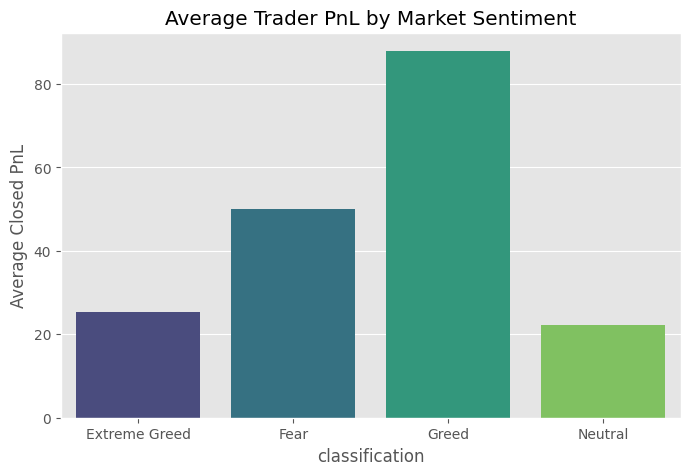

In [536]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='classification',
    y='Closed PnL',
    data=pnl_by_sentiment,
    palette='viridis'
)

plt.title("Average Trader PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

**Win Rate Analysis Across Market Sentiment**

The win rate represents the proportion of trades that resulted in a positive 
profit (Closed PnL > 0). By comparing win rates across sentiment categories 
such as Fear, Greed, Extreme Greed, and Neutral, we can evaluate whether market conditions influence the likelihood of successful trades.

The bar chart below visualizes the average win rate for each sentiment category.

C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\388278338.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='win', data=data, palette='viridis')


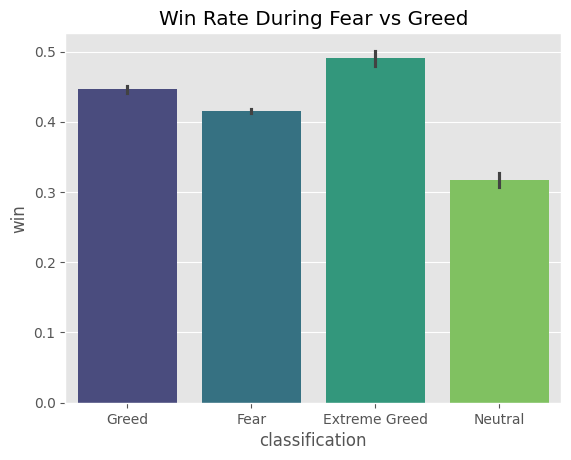

In [537]:

sns.barplot(x='classification', y='win', data=data, palette='viridis')

plt.title("Win Rate During Fear vs Greed")

plt.show()

**Trade Activity Across Market Sentiment**

In addition to analyzing profitability, it is important to understand how 
trading activity changes under different market sentiment conditions.

To measure trading activity, we count the number of trades executed during 
each sentiment category (Fear, Greed, Extreme Greed, and Neutral).

This helps identify whether traders become more active during optimistic 
market phases or more cautious during uncertain periods.

C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\1490053131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='num_trades', data=trades_by_sentiment, palette='viridis')


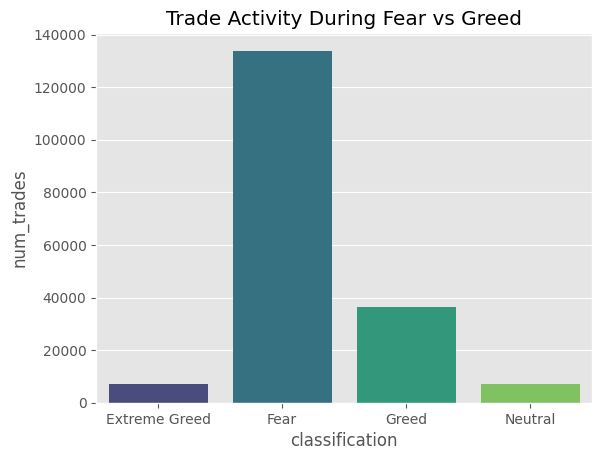

In [538]:
trades_by_sentiment = data.groupby('classification').size().reset_index(name='num_trades')

trades_by_sentiment
sns.barplot(x='classification', y='num_trades', data=trades_by_sentiment, palette='viridis')

plt.title("Trade Activity During Fear vs Greed")

plt.show()

**Long vs Short Trading Behavior Across Market Sentiment**

To better understand trader decision-making, we analyze how traders choose 
between long and short positions under different market sentiment conditions.

A long position indicates that a trader expects the price of an asset to rise, 
while a short position indicates an expectation that the price will fall.

By comparing the distribution of long and short trades across different sentiment categories (Fear, Greed, Extreme Greed, and Neutral), we can observe whether market psychology influences directional trading behavior.

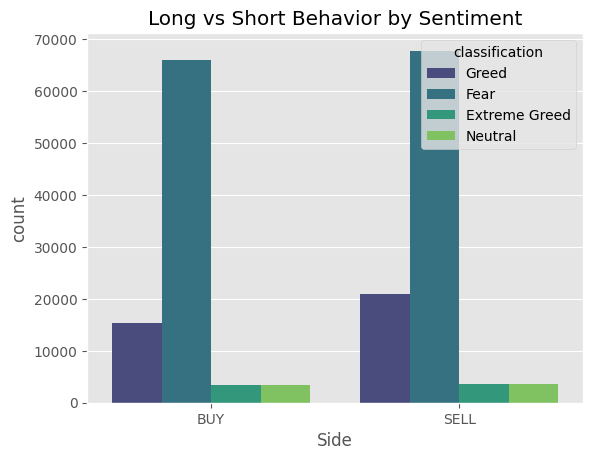

In [539]:
pd.crosstab(data['classification'], data['Side'])
sns.countplot(x='Side', hue='classification', data=data , palette='viridis')

plt.title("Long vs Short Behavior by Sentiment")

plt.show()

**Trader Segmentation: Frequent vs Infrequent Traders**

In this analysis, traders are segmented based on how frequently they trade.

Frequent traders are defined as traders who execute a higher number of trades 
than the median trade count across all traders.

Infrequent traders execute fewer trades compared to the median.

This segmentation helps identify whether higher trading activity is associated 
with better or worse performance.

In [540]:
trade_counts = data.groupby('Account').size().reset_index(name='trade_count')

trade_counts.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


To classify traders, we calculate the median number of trades. 
Traders above the median are categorized as Frequent Traders, 
while those below the median are categorized as Infrequent Traders.

In [541]:
median_trades = trade_counts['trade_count'].median()

trade_counts['trader_type'] = trade_counts['trade_count'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

trade_counts.head()

,Account,trade_count,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\3255576402.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=trade_counts, x='trader_type', palette='Set2')


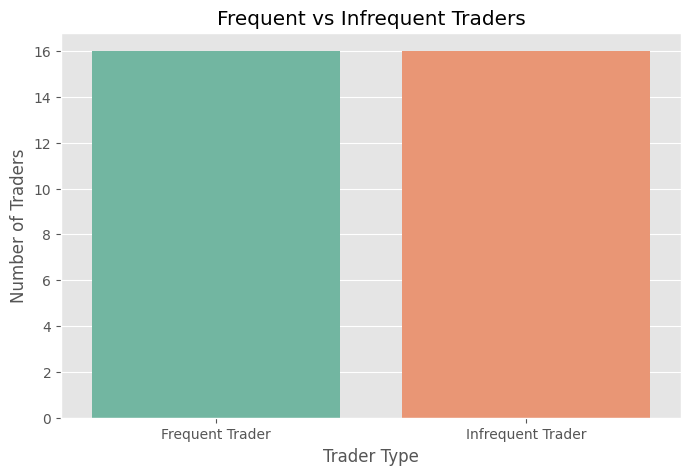

In [542]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(data=trade_counts, x='trader_type', palette='Set2')

plt.title("Frequent vs Infrequent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")

plt.show()

***Trader Segmentation: Consistent vs Inconsistent Traders***

Win rate represents the percentage of trades that result in positive profit.

Traders with a win rate greater than 60% are classified as Consistent Winners, 
while traders with lower win rates are classified as Inconsistent Traders.

This segmentation helps identify traders who are able to maintain consistent profitability.

In [543]:
# Calculate win rate per trader
win_rate = data.groupby('Account').apply(
    lambda x: (x['Closed PnL'] > 0).mean()
).reset_index(name='win_rate')

win_rate['trader_segment'] = win_rate['win_rate'].apply(
    lambda x: 'Consistent Winner' if x > 0.6 else 'Inconsistent Trader'
)

win_rate.head()

C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\2654208089.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate = data.groupby('Account').apply(


,Account,win_rate,trader_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,Inconsistent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,Inconsistent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,Inconsistent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,Inconsistent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,Inconsistent Trader


C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\3742449266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=win_rate, x='trader_segment', palette='coolwarm')


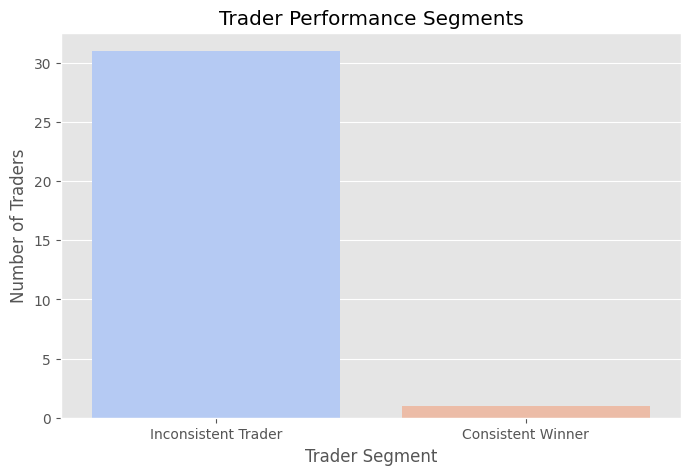

In [544]:
plt.figure(figsize=(8,5))

sns.countplot(data=win_rate, x='trader_segment', palette='coolwarm')

plt.title("Trader Performance Segments")
plt.xlabel("Trader Segment")
plt.ylabel("Number of Traders")

plt.show()

***Insight 1: Market Sentiment Influences Trader Profitability***

To understand how market sentiment affects trading performance, we analyze 
the average profit and loss (PnL) of trades during different sentiment phases.

By grouping trades by sentiment classification (Fear vs Greed), we can 
observe whether traders perform better during optimistic or pessimistic 
market conditions.

In [545]:
avg_pnl_sentiment = data.groupby('classification')['Closed PnL'].mean().reset_index()

avg_pnl_sentiment

,classification,Closed PnL
0,Extreme Greed,25.418772
1,Fear,50.047622
2,Greed,87.894859
3,Neutral,22.229713


C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\2323298113.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


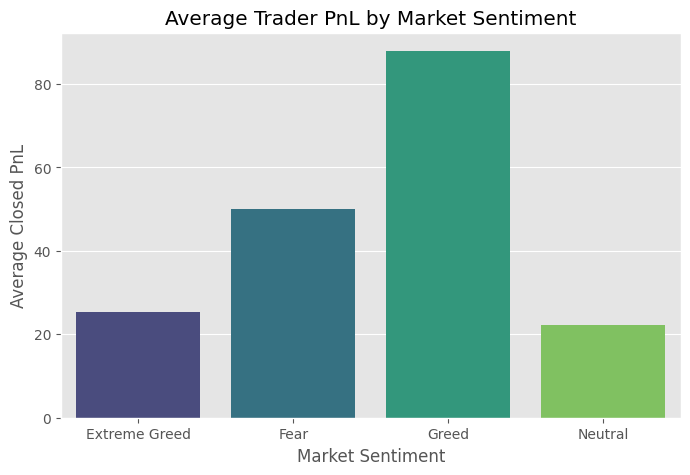

In [546]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(
    data=avg_pnl_sentiment,
    x='classification',
    y='Closed PnL',
    palette='viridis'
)

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

**Observation:**
Among the different sentiment categories, the highest average trader profit 
appears during Greed phases, while lower profitability is observed during 
Neutral and Extreme Greed conditions.

**Interpretation:**
This suggests that traders tend to perform better when market sentiment is 
optimistic but not excessively overheated. During extreme greed phases, 
market volatility may increase, which can reduce overall profitability.

***Insight 2: Frequent Traders Contribute Most of the Trading Activity***

Traders are segmented into frequent and infrequent groups based on the 
number of trades executed.

This helps us understand whether a small group of traders accounts for 
a large portion of total trading activity.

In [547]:
trade_counts = data.groupby('Account').size().reset_index(name='trade_count')

median_trades = trade_counts['trade_count'].median()

trade_counts['trader_type'] = trade_counts['trade_count'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

trade_counts.head()

,Account,trade_count,trader_type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


C:\Users\sinha\AppData\Local\Temp\ipykernel_96396\4019847992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=trade_counts, x='trader_type', palette='Set2')


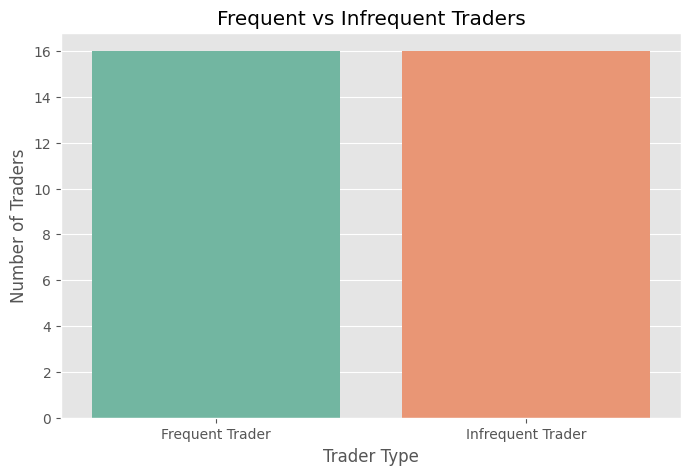

In [548]:
plt.figure(figsize=(8,5))

sns.countplot(data=trade_counts, x='trader_type', palette='Set2')

plt.title("Frequent vs Infrequent Traders")
plt.xlabel("Trader Type")
plt.ylabel("Number of Traders")

plt.show()

**Observation:**
The chart shows that the number of frequent and infrequent traders is 
almost evenly distributed.

**Interpretation:**
This indicates that trading activity is relatively balanced across the 
user base. The market is not dominated by a small group of extremely 
active traders, suggesting a diverse mix of trading behaviors.

***Strategy 1: Increase Trading Activity During Greed Phases***

Based on the analysis, traders appear to achieve higher average profits during 
periods of market greed.

Rule of Thumb:
When market sentiment indicates Greed, traders may consider increasing 
their trading activity or position sizes to take advantage of strong market trends.

Reasoning:
Greed phases often correspond with bullish market conditions where price momentum 
is stronger. These conditions can increase the likelihood of profitable trades.

***Strategy 2: Maintain Consistent Risk Management for Frequent Traders***

The segmentation analysis shows that both frequent and infrequent traders 
participate actively in the market.

Rule of Thumb:
Frequent traders should implement strict risk management strategies such as 
stop-loss orders and position sizing rules to avoid large cumulative losses 
from multiple trades.

Reasoning:
Frequent trading increases exposure to market volatility, making disciplined 
risk management essential for maintaining long-term profitability.